In [9]:
import pandas as pd
from tabulate import tabulate
import numpy as np
import os
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import rasterio
import plotly.express as px
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt



#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("../tools"))
import functions

In [ ]:

aez_path = "../../../../data/finaldatasets/covariates/Covariates/aez_v9v2red_5m_CRUTS32_Hist_8110_100_avg.tif"
aez = rasterio.open(aez_path)

/tmp/ipykernel_112533/2721028212.py:1: DtypeWarning: Columns (14,15,16,17,20,22,23,24,26,27,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/finalfrfr/jittered_eng_cleaned.csv", header=0, sep=",")


/tmp/ipykernel_112533/2396256604.py:21: DtypeWarning: Columns (14,15,16,17,20,22,23,24,26,27,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/finalfrfr/jittered_eng_cleaned.csv")


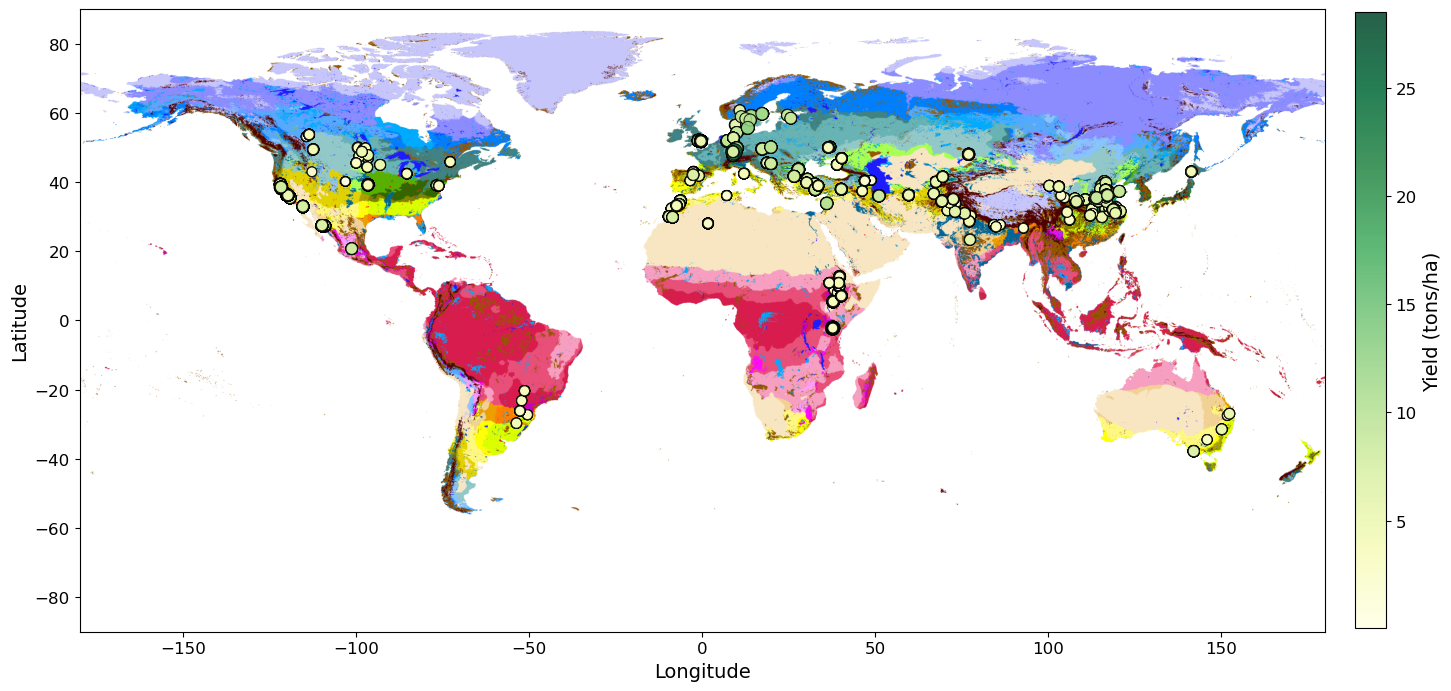

In [23]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib as mpl

# --- Load AEZ raster with original palette colors ---
aez_path = "../../../../data/finaldatasets/covariates/Covariates/aez_v9v2red_5m_CRUTS32_Hist_8110_100_avg.tif"
with rasterio.open(aez_path) as src:
    aez_data = src.read(1)
    transform = src.transform
    bounds = src.bounds
    aez_crs = src.crs
    colormap = src.colormap(1)

cmap_array = np.array([colormap[i] for i in range(len(colormap))], dtype=np.uint8)[:, :3]
aez_rgb = cmap_array[aez_data]

# --- Load and prep yield data ---
df = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/finalfrfr/jittered_eng_cleaned.csv")
df = df[["Conversion.for.latitude", "Conversion.for.longitude", "Grain.yield..tons.ha.1.", "year"]]
df = df.rename(columns={
    "Conversion.for.latitude": "latitude",
    "Conversion.for.longitude": "longitude",
    "Grain.yield..tons.ha.1.": "yield"
})

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
gdf = gdf.to_crs(aez_crs)

# Bubble size scaling
size_scale = 100  # much larger bubbles
sizes = (gdf["yield"] / gdf["yield"].max()) * size_scale + 40

# Normalized colors
norm = mpl.colors.Normalize(vmin=gdf["yield"].min(), vmax=gdf["yield"].max())
cmap = plt.cm.YlGn

fig, ax = plt.subplots(figsize=(16, 8))

# Base AEZ raster
ax.imshow(aez_rgb, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

# --- Drop shadow for bubbles (black background circles) ---
ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    s=sizes,
    color="black",
    alpha=0.5,
    zorder=2
)

# --- Main bubbles with white outlines ---
scatter = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    s=sizes,
    c=gdf["yield"],
    cmap=cmap,
    norm=norm,
    alpha=0.85,             # nearly opaque
    edgecolors="black",     # outline color
    linewidth=0.7,          # outline thickness
    zorder=3
)

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Yield (tons/ha)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Titles and labels
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("aez_yield_bubbles_highviz.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
finalfinalsadsadsadsads   adsadsadsadsadsa